### Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Load the Dataset

In [3]:
df = pd.read_csv("311_Service_Requests_for_2009.csv",low_memory=False)

In [4]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,12822544,01/01/2009 12:00:00 AM,01/07/2009 12:00:00 AM,HPD,Department of Housing Preservation and Develop...,HEATING,HEAT,RESIDENTIAL BUILDING,11225,55 WINTHROP STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.656621,-73.958066,"(40.65662129596871, -73.95806621423951)"
1,12818524,01/01/2009 12:00:00 AM,NaN,DOHMH,Department of Health and Mental Hygiene,Smoking,Smoking Violation,Restaurant/Bar/Deli/Bakery,11102,29-35 NEWTOWN AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.768896,-73.921818,"(40.76889608950418, -73.92181786912313)"
2,12823061,01/01/2009 12:00:00 AM,01/01/2009 12:00:00 AM,DOT,Department of Transportation,Traffic Signal Condition,Controller,NaN,11220,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.635345,-74.016822,"(40.635344653337626, -74.01682221017914)"
3,12823062,01/01/2009 12:00:00 AM,01/01/2009 12:00:00 AM,DOT,Department of Transportation,Traffic Signal Condition,Controller,NaN,11201,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.698378,-73.983050,"(40.698378448801606, -73.98305008771115)"
4,12823063,01/01/2009 12:00:00 AM,01/01/2009 12:00:00 AM,DOT,Department of Transportation,Traffic Signal Condition,Controller,NaN,11235,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.592752,-73.950152,"(40.59275234651692, -73.95015246435702)"


In [5]:
df.shape

(1783133, 52)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1783133 entries, 0 to 1783132
Data columns (total 52 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   Unique Key                      int64  
 1   Created Date                    str    
 2   Closed Date                     str    
 3   Agency                          str    
 4   Agency Name                     str    
 5   Complaint Type                  str    
 6   Descriptor                      str    
 7   Location Type                   str    
 8   Incident Zip                    str    
 9   Incident Address                str    
 10  Street Name                     str    
 11  Cross Street 1                  str    
 12  Cross Street 2                  str    
 13  Intersection Street 1           str    
 14  Intersection Street 2           str    
 15  Address Type                    str    
 16  City                            str    
 17  Landmark                        str   

In [7]:
df = df.sample(frac=1,random_state=42)

In [8]:
df.reset_index(drop=True,inplace=True)

In [9]:
df = df[0:20000]

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      20000 non-null  int64  
 1   Created Date                    20000 non-null  str    
 2   Closed Date                     19320 non-null  str    
 3   Agency                          20000 non-null  str    
 4   Agency Name                     20000 non-null  str    
 5   Complaint Type                  20000 non-null  str    
 6   Descriptor                      19943 non-null  str    
 7   Location Type                   13542 non-null  str    
 8   Incident Zip                    18593 non-null  str    
 9   Incident Address                15749 non-null  str    
 10  Street Name                     15745 non-null  str    
 11  Cross Street 1                  15691 non-null  str    
 12  Cross Street 2                  15584 non-n

In [11]:
df = df[['Created Date','Complaint Type','Descriptor', 'Borough']]
df.head(10)

,Created Date,Complaint Type,Descriptor,Borough
0,05/19/2009 12:00:00 AM,Street Light Condition,Street Light Out,QUEENS
1,01/20/2009 12:00:00 AM,Snow,5 Un-Plowed/Spread Street,BROOKLYN
2,01/07/2009 12:00:00 AM,Street Light Condition,Street Light Out,STATEN ISLAND
3,04/04/2009 12:00:00 AM,Water System,Possible Water Main Break (Use Comments) (WA1),BRONX
4,01/23/2009 12:00:00 AM,Electrical,Electrical Wiring Defective/Exposed,BROOKLYN
5,04/24/2009 12:00:00 AM,NONCONST,SMOKE-DETECTOR,Unspecified
6,08/13/2009 12:00:00 AM,NONCONST,VERMIN,Unspecified
7,10/22/2009 12:00:00 AM,Street Condition,Failed Street Repair,BRONX
8,03/30/2009 12:00:00 AM,Hazardous Materials,Chemical Odor (HD1),QUEENS
9,03/07/2009 12:00:00 AM,GENERAL CONSTRUCTION,WINDOWS,Unspecified


In [12]:
#missing values
df.isna().sum()

Created Date       0
Complaint Type     0
Descriptor        57
Borough            0
dtype: int64

In [13]:
#filling missing values
df['Complaint Type'] = df['Complaint Type'].fillna('Unknown')
df['Descriptor'] = df['Descriptor'].fillna('Unknown')
df['Borough'] = df['Borough'].fillna('Unknown')

In [14]:
df.shape

(20000, 4)

In [15]:
df['text'] = df['Complaint Type'] + ' ' + df['Descriptor']

In [16]:
df['Complaint Type'].unique()

<StringArray>
[     'Street Light Condition',                        'Snow',
                'Water System',                  'Electrical',
                    'NONCONST',            'Street Condition',
         'Hazardous Materials',        'GENERAL CONSTRUCTION',
                    'PLUMBING',                       'Sewer',
 ...
                        'Mold',         'Illegal Animal Sold',
             'Ferry Complaint',             'Scaffold Safety',
               'Public Toilet',  'Unsanitary Animal Facility',
           'Illegal Fireworks',  'Municipal Parking Facility',
 'Animal Facility - No Permit',     'Senior Center Complaint']
Length: 126, dtype: str

In [17]:
df['Complaint Type'].value_counts()

Complaint Type
HEATING                        2583
Street Light Condition         1479
GENERAL CONSTRUCTION           1362
PLUMBING                       1234
Street Condition               1154
                               ... 
Illegal Animal Sold               1
Public Toilet                     1
Unsanitary Animal Facility        1
Municipal Parking Facility        1
Animal Facility - No Permit       1
Name: count, Length: 126, dtype: int64

In [18]:
df.groupby('Complaint Type').size()

Complaint Type
APPLIANCE                      173
Air Quality                    107
Animal Facility - No Permit      1
Animal in a Park                13
Asbestos                        15
                              ... 
Violation of Park Rules         23
Water Conservation              39
Water Quality                   14
Water System                   697
Window Guard                    11
Length: 126, dtype: int64

### Text Preprocessing

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(sentence):
    text = str(sentence).lower()  # Convert to lowercase
    
    text = re.sub(r"http\S+|www\S+", " ", text) # Remove URLs
    
    text = re.sub(r"[^a-zA-Z0-9]", " ", text) # Remove special characters

    words = text.split() 
    
# Remove stopwords + apply lemmatization
    
    words = [x for x in words if x not in stop_words]
    words = [lemmatizer.lemmatize(word, 'v') for word in words]

    return " ".join(words)

In [20]:
df['clean_text'] = df['text'].apply(preprocess)
df[['text','clean_text']].head()

,text,clean_text
0,Street Light Condition Street Light Out,street light condition street light
1,Snow 5 Un-Plowed/Spread Street,snow 5 un plow spread street
2,Street Light Condition Street Light Out,street light condition street light
3,Water System Possible Water Main Break (Use Co...,water system possible water main break use com...
4,Electrical Electrical Wiring Defective/Exposed,electrical electrical wire defective expose


In [21]:
for i in range(10):
    print(df['clean_text'][i], '- ', df['Complaint Type'][i])
    print()

street light condition street light -  Street Light Condition

snow 5 un plow spread street -  Snow

street light condition street light -  Street Light Condition

water system possible water main break use comment wa1 -  Water System

electrical electrical wire defective expose -  Electrical

nonconst smoke detector -  NONCONST

nonconst vermin -  NONCONST

street condition fail street repair -  Street Condition

hazardous materials chemical odor hd1 -  Hazardous Materials

general construction windows -  GENERAL CONSTRUCTION



### Exploratory Data Analysis

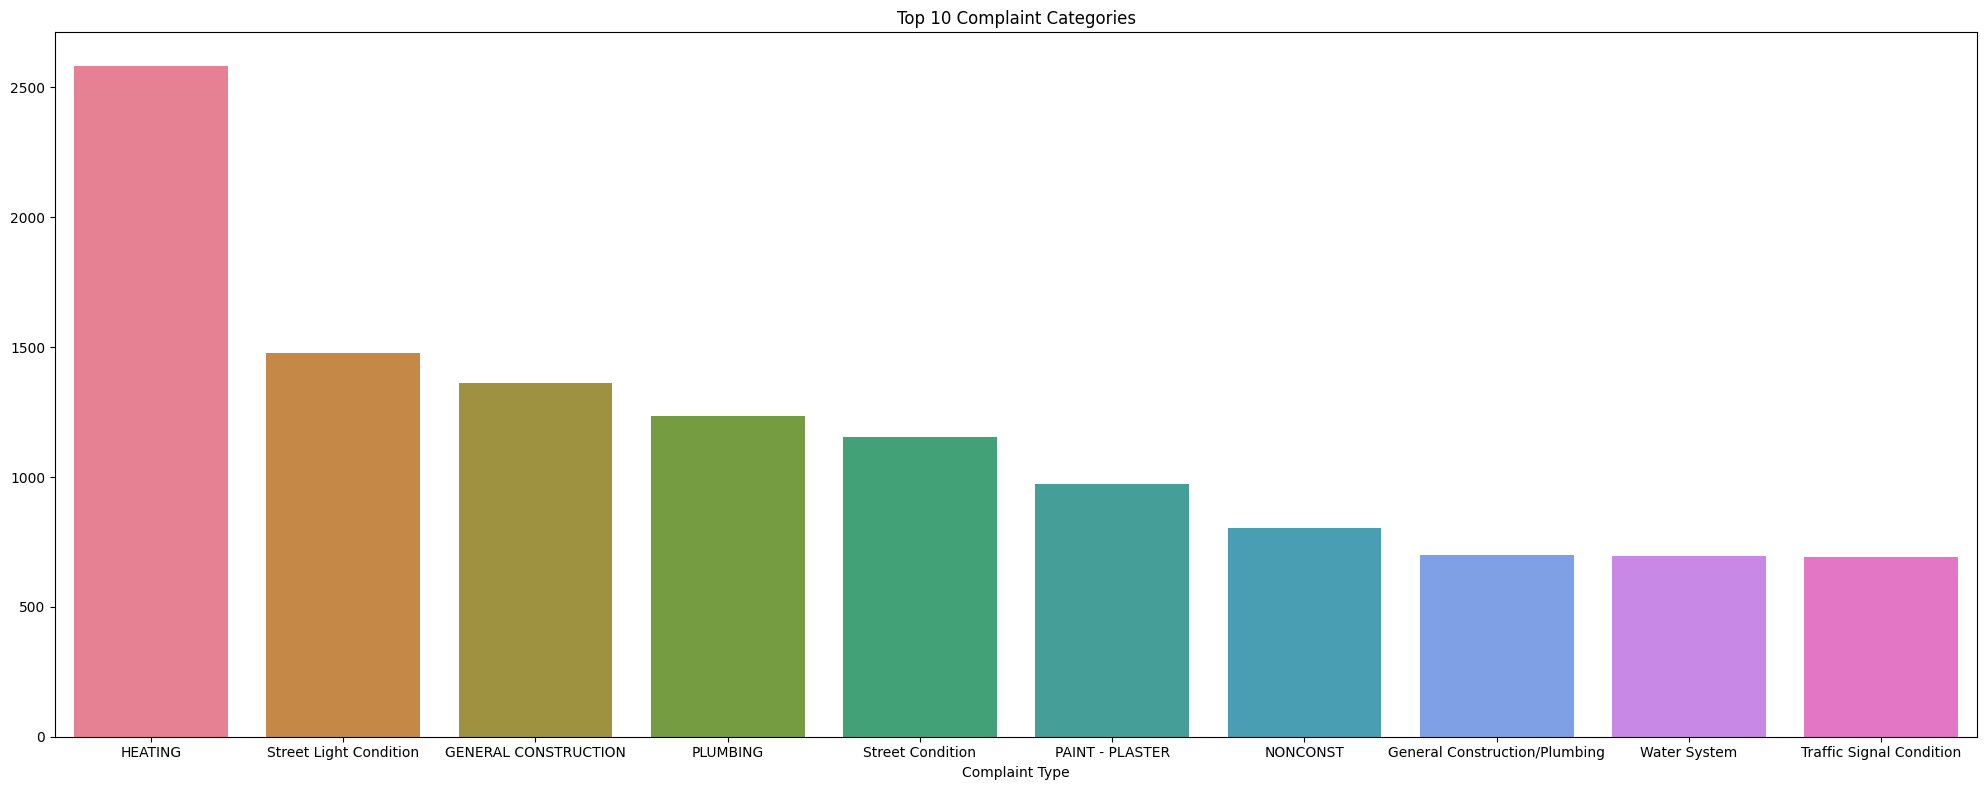

In [22]:
top_15 = df['Complaint Type'].value_counts().head(10)

plt.figure(figsize=(20,8))
sns.barplot(x = top_15.index, y = top_15.values, palette = 'husl', hue = top_15.index, legend = False)
plt.title('Top 10 Complaint Categories')
plt.tight_layout()
plt.show()

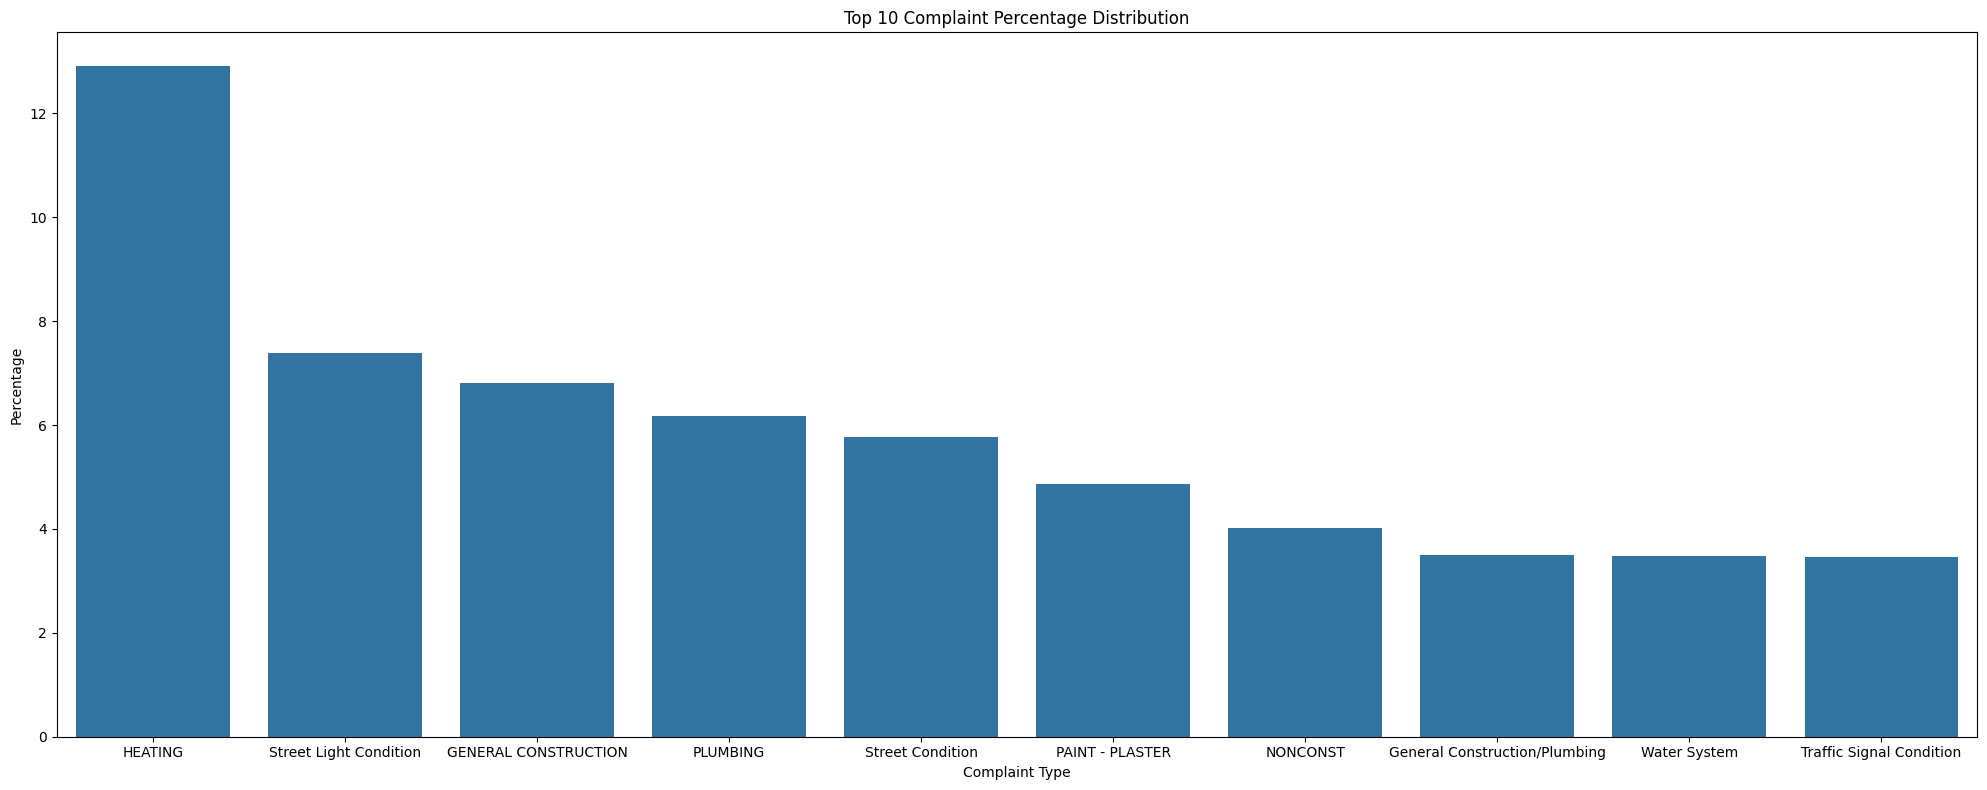

In [23]:
complaint_percentage = df['Complaint Type'].value_counts(normalize=True).head(10)*100

plt.figure(figsize=(20,8))
sns.barplot(x = complaint_percentage.index, y = complaint_percentage.values)
plt.ylabel('Percentage')
plt.title('Top 10 Complaint Percentage Distribution')
plt.tight_layout()
plt.show()

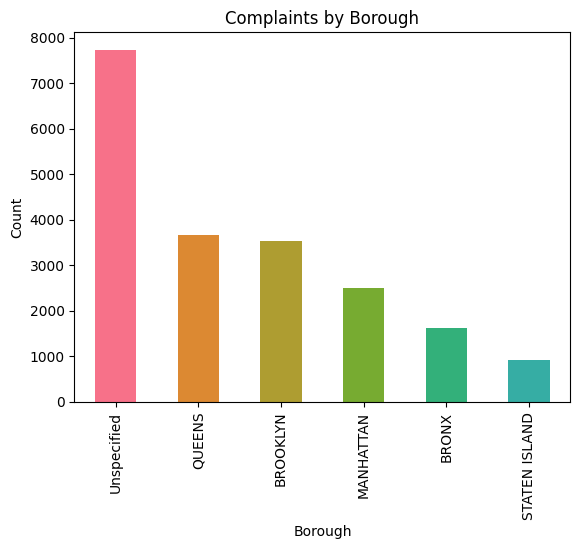

In [24]:
colors = sns.color_palette("husl", 10)

df['Borough'].value_counts().plot(kind='bar', color = colors)
plt.title("Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.show()

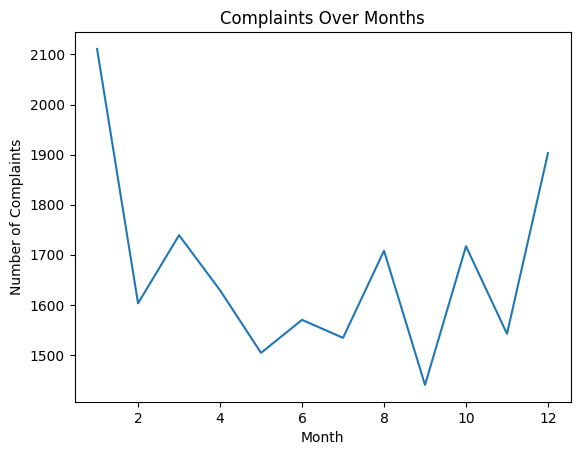

In [25]:
#Time Series Complaint Trend Analysis
df['Created Date'] = pd.to_datetime(
    df['Created Date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

df['Created Date'].dt.month.value_counts().sort_index().plot()
plt.title("Complaints Over Months")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.show()

### Word Clouds

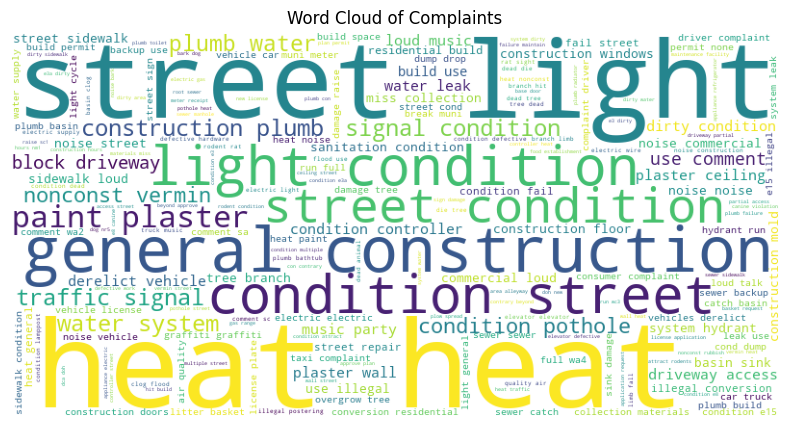

In [26]:
text_data = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud of Complaints")
plt.show()

### N-grams Frequency Distribution

In [27]:
#Unigram

vectorizer = CountVectorizer(ngram_range=(1,1), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

unigram_df = pd.DataFrame({'word': words, 'count': counts})
unigram_df.sort_values(by='count', ascending=False)

,word,count
4,heat,5211
8,street,5015
1,condition,4573
5,light,2887
2,construction,2258
3,general,2098
7,plumb,1999
9,water,1620
6,noise,1588
0,build,1004


In [28]:
#bigram

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
X = vectorizer.fit_transform(df['clean_text'])

bigrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({'bigram': bigrams, 'count': counts})
bigram_df.sort_values(by='count', ascending=False)

,bigram,count
7,street light,2747
3,heat heat,2583
2,general construction,2062
4,light condition,1479
0,condition street,1187
6,street condition,1167
5,paint plaster,972
1,construction plumb,702
8,traffic signal,702
9,water system,697


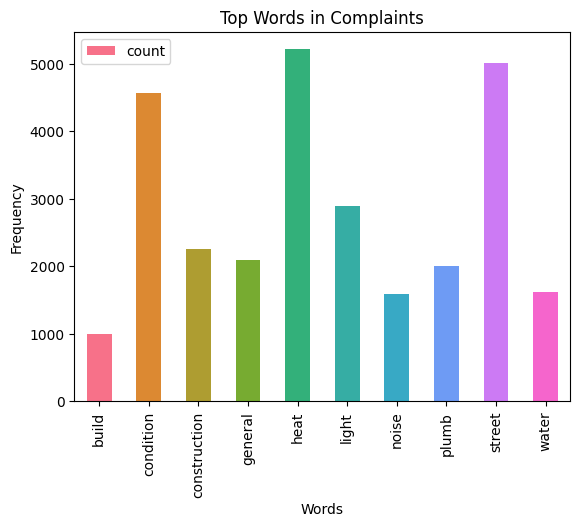

In [29]:
unigram_df.plot(x='word', y='count', kind='bar', color=colors)
plt.title("Top Words in Complaints")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

### Assign the feature and target variables

In [30]:
X = df['clean_text']
y = df['Complaint Type']

### Transform X variable using TF-IDF Vectorizer

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))

In [33]:
X = vectorizer.fit_transform(X)

### Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)

# Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)
lr_model.score(X_train,y_train)

0.9964375

### Cross Validation of Logistic Regression

In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_model, X, y, cv=3, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Cross-validation scores: [0.99415029 0.9940003  0.99489949]
Mean CV accuracy: 0.9943500274731237


### Evaluation of Logistic Regression Model

Accuracy of Logistic Regression model is : 0.99175


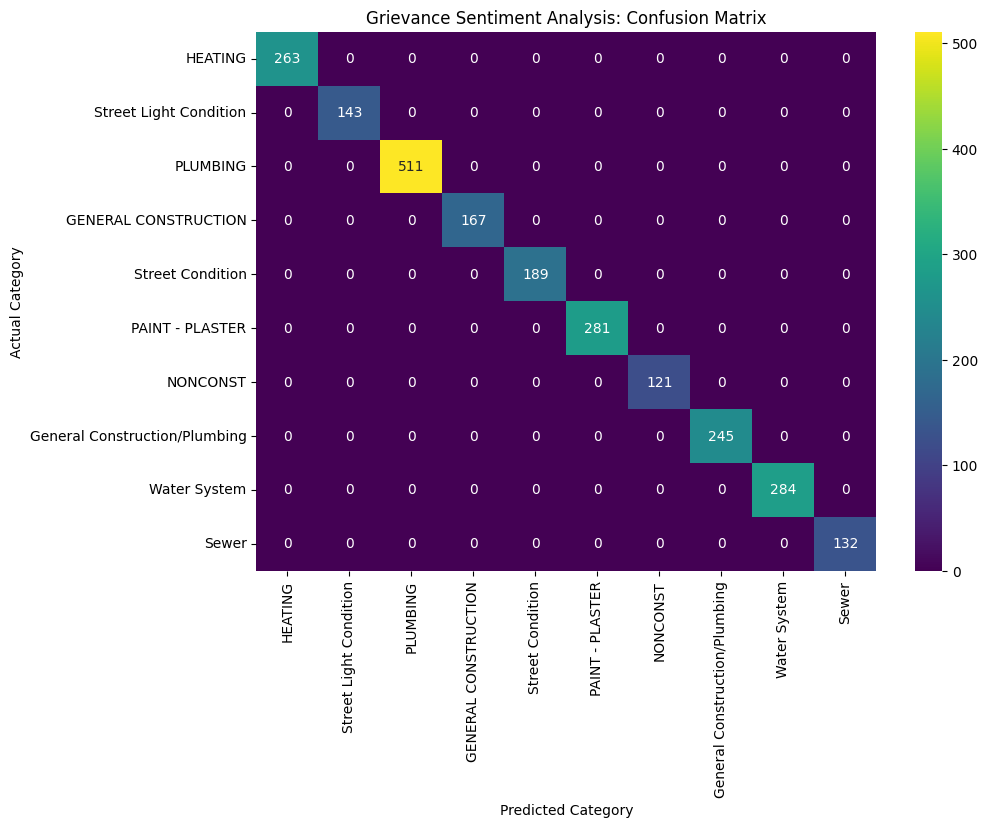

Classification Report of Logistic Regression model
 is :                                            precision    recall  f1-score   support

                                APPLIANCE       1.00      0.97      0.99        34
                              Air Quality       0.96      1.00      0.98        24
              Animal Facility - No Permit       0.00      0.00      0.00         1
                         Animal in a Park       0.50      1.00      0.67         1
                                 Asbestos       1.00      1.00      1.00         5
                         BEST/Site Safety       1.00      1.00      1.00         2
               Beach/Pool/Sauna Complaint       0.00      0.00      0.00         1
                Bike/Roller/Skate Chronic       1.00      1.00      1.00         1
                         Blocked Driveway       1.00      1.00      1.00       102
                                  Boilers       1.00      1.00      1.00         8
                         Brid

c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

In [38]:
# Predictions
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
lr_pred = lr_model.predict(X_test)

# Accuracy

print("Accuracy of Logistic Regression model is :", accuracy_score(y_test,lr_pred))

# Select top 10 most frequent classes
top_classes = y_test.value_counts().index[:10]

# Filter data
mask = y_test.isin(top_classes)
y_test_top = y_test[mask]
lr_pred_top = lr_pred[mask]

# Confusion Matrix
cm = confusion_matrix(y_test_top,lr_pred_top)
plt.figure(figsize=(10,7))

# Heatmap
sns.heatmap(cm,annot=True,fmt='d',cmap='viridis',xticklabels = top_classes,yticklabels = top_classes)
plt.title("Grievance Sentiment Analysis: Confusion Matrix")
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()
print("Classification Report of Logistic Regression model\n is :", classification_report(y_test,lr_pred))


## random forest

In [39]:
### random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Assuming you already have:
# X_train, X_test, y_train, y_test

# 1. Create model
rf_model = RandomForestClassifier(n_estimators=100,max_depth=20, random_state=42)

# 2. Train model
rf_model.fit(X_train, y_train)

# 3. Predictions
y_pred = rf_model.predict(X_test)

# 4. Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# 5. Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Cross Validation (on training data)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())


Test Accuracy: 0.91575

Classification Report:
                                            precision    recall  f1-score   support

                                APPLIANCE       1.00      1.00      1.00        34
                              Air Quality       1.00      0.54      0.70        24
              Animal Facility - No Permit       0.00      0.00      0.00         1
                         Animal in a Park       0.00      0.00      0.00         1
                                 Asbestos       0.00      0.00      0.00         5
                         BEST/Site Safety       0.00      0.00      0.00         2
               Beach/Pool/Sauna Complaint       0.00      0.00      0.00         1
                Bike/Roller/Skate Chronic       0.00      0.00      0.00         1
                         Blocked Driveway       1.00      1.00      1.00       102
                                  Boilers       0.00      0.00      0.00         8
                         Bridge Condit

c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0


Cross Validation Scores: [0.9128125 0.9140625 0.913125  0.90875   0.910625 ]
Average CV Score: 0.911875


## comparision of lr and rf with confusion matrix

📊 Model Comparison:
Logistic Regression Accuracy: 0.99175
Random Forest Accuracy: 0.99825


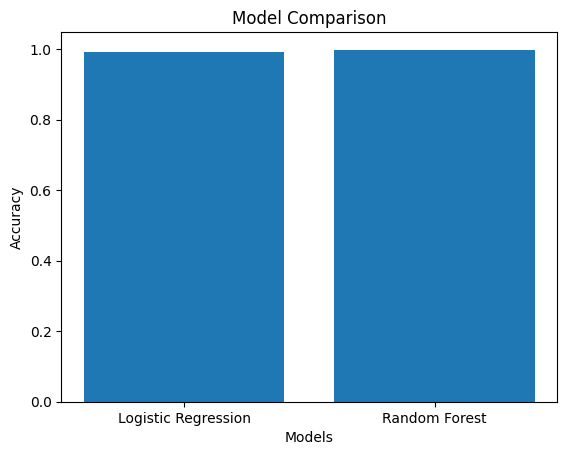


Confusion Matrix - Logistic Regression (Top 10 Classes)


<Figure size 800x600 with 0 Axes>

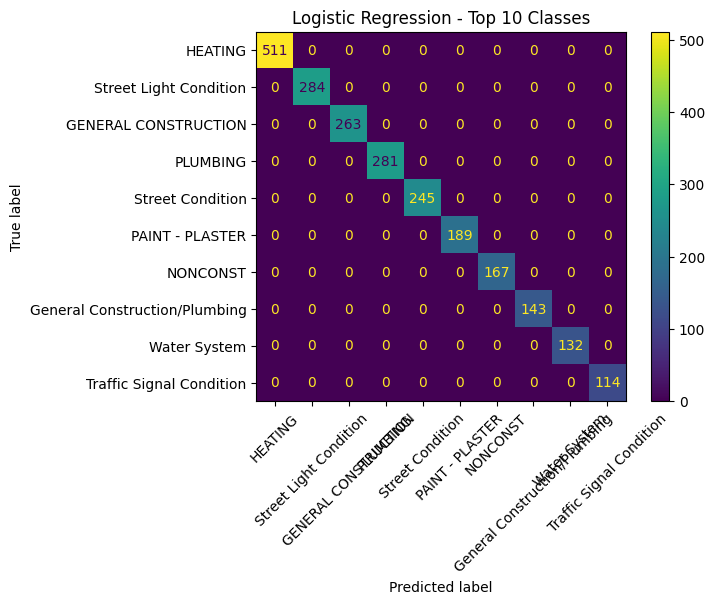


Confusion Matrix - Random Forest (Top 10 Classes)


<Figure size 800x600 with 0 Axes>

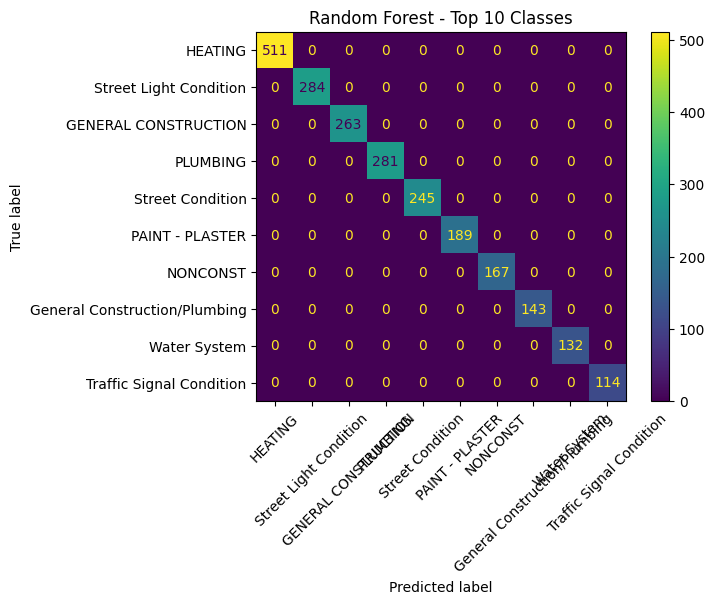

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -------- Logistic Regression --------
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# -------- Random Forest --------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# -------- Comparison --------
print("📊 Model Comparison:")
print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

# -------- Bar Graph --------
models = ['Logistic Regression', 'Random Forest']
scores = [lr_acc, rf_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()


import numpy as np


top_classes = y.value_counts().nlargest(10).index

# Filter test data
mask = y_test.isin(top_classes)

y_test_filtered = y_test[mask]
lr_pred_filtered = lr_pred[mask]
rf_pred_filtered = rf_pred[mask]

# Logistic Regression CM 
print("\nConfusion Matrix - Logistic Regression (Top 10 Classes)")
cm_lr = confusion_matrix(y_test_filtered, lr_pred_filtered, labels=top_classes)

plt.figure(figsize=(8,6))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=top_classes)
disp_lr.plot(xticks_rotation=45)
plt.title("Logistic Regression - Top 10 Classes")
plt.show()

# Random Forest CM 
print("\nConfusion Matrix - Random Forest (Top 10 Classes)")
cm_rf = confusion_matrix(y_test_filtered, rf_pred_filtered, labels=top_classes)

plt.figure(figsize=(8,6))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=top_classes)
disp_rf.plot(xticks_rotation=45)
plt.title("Random Forest - Top 10 Classes")
plt.show()

## cross validation

In [41]:
from sklearn.model_selection import cross_val_score

# Cross Validation (5-fold)
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross Validation Scores: [1.      0.99925 0.99875 0.99925 0.99975]
Average CV Score: 0.9994


## Stratified CV

In [42]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=cv)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

c:\Users\User\OneDrive\Desktop\AI-Driven Citizen Grievance & Sentiment Analysis System\venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


CV Scores: [0.99925 0.999   0.99925 0.999   1.     ]
Mean CV Score: 0.9993000000000001
